In [1]:
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

In [2]:
print(os.getcwd())
!ls
customers = pd.read_csv("data/DM_AIAI_CustomerDB.csv")
flights = pd.read_csv("data/DM_AIAI_FlightsDB.csv")

customers


/Users/ammar/Documents/Data Mining - Practical/Data-Mining-Project
DM_project_customersdb_Marta.ipynb Project Guidelines-20251009
DM_project_flightsdb_Marta.ipynb   README.md
Data Mining Project.ipynb          data
Last_Year_Project


,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,...,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,...,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,...,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,...,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,...,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16916,15,100012,Ethan,Thompson,Ethan Thompson,Canada,Quebec,Quebec City,46.759733,-71.141009,...,male,Bachelor,Suburban,NaN,Single,Star,2/27/2019,2/27/2019,NaN,Standard
16917,16,100013,Layla,Young,Layla Young,Canada,Alberta,Edmonton,53.524829,-113.546357,...,female,Bachelor,Rural,NaN,Married,Star,9/20/2017,9/20/2017,NaN,Standard
16918,17,100014,Amelia,Bennett,Amelia Bennett,Canada,New Brunswick,Moncton,46.051866,-64.825428,...,male,Bachelor,Rural,NaN,Married,Star,11/28/2020,11/28/2020,NaN,Standard
16919,18,100015,Benjamin,Wilson,Benjamin Wilson,Canada,Quebec,Quebec City,46.862970,-71.133444,...,female,College,Urban,NaN,Married,Star,4/9/2020,4/9/2020,NaN,Standard


In [3]:
print(len(customers['Loyalty#'].unique()), len(customers))

16757 16921


In [4]:
customers.drop('Unnamed: 0', axis=1, inplace=True)
customers.drop('First Name', axis=1, inplace=True)
customers.drop('Last Name', axis=1, inplace=True)
columns_to_drop = ['Country']
customers.drop(columns=columns_to_drop, inplace=True)
#Drop these or not? 2 Yes 1 No

customers['EnrollmentDateOpening'] = pd.to_datetime(customers['EnrollmentDateOpening'], errors='coerce')
customers['CancellationDate'] = pd.to_datetime(customers['CancellationDate'], errors='coerce')

# TO remove fligts month and year and transform Yearmonthdate





In [5]:
customers

,Loyalty#,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard
1,549612,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,2019-03-09,NaT,3839.61,Standard
2,429460,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard
3,608370,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2016-02-17,NaT,3839.75,Standard
4,530508,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,2017-10-25,NaT,3842.79,2021 Promotion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16916,100012,Ethan Thompson,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,NaN,Single,Star,2019-02-27,2019-02-27,NaN,Standard
16917,100013,Layla Young,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,NaN,Married,Star,2017-09-20,2017-09-20,NaN,Standard
16918,100014,Amelia Bennett,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,NaN,Married,Star,2020-11-28,2020-11-28,NaN,Standard
16919,100015,Benjamin Wilson,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,NaN,Married,Star,2020-04-09,2020-04-09,NaN,Standard


In [6]:
flights.sort_values(by='Loyalty#')

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
574634,100018,2019,11,11/1/2019,11.7,0.9,20838.6,2083.86,0.0,0.0
381629,100018,2020,7,7/1/2020,10.0,0.0,29957.0,2995.00,0.0,0.0
284507,100018,2020,12,12/1/2020,6.0,0.0,14197.0,1419.00,0.0,0.0
58876,100018,2020,3,3/1/2020,14.0,3.0,13706.0,1370.00,3468.0,34.0
405624,100018,2019,1,1/1/2019,2.7,0.0,11070.0,1107.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
317124,999986,2020,11,11/1/2020,0.0,0.0,0.0,0.00,0.0,0.0
66275,999986,2020,2,2/1/2020,7.0,0.0,23810.0,2381.00,0.0,0.0
58925,999986,2020,3,3/1/2020,13.0,3.0,26485.0,2648.00,0.0,0.0
18603,999986,2020,5,5/1/2020,13.0,0.0,5137.0,513.00,0.0,0.0


In [7]:
# def encode_column(df):
#     columns_to_encode = ["Gender", "Education", "Location Code", "Marital Status", "LoyaltyStatus", "EnrollmentType"]
#     for column_name in columns_to_encode:
#         unique_values = df[column_name].unique()
#         mapping_dict = {}
#         index = 0
    
#         for value in unique_values:
#             mapping_dict[value] = index
#             index += 1
    
#         df[column_name] = df[column_name].map(mapping_dict)
#         print(f"Mapping for '{column_name}': {mapping_dict}")

# encode_column(customers)
# customers

In [8]:
print("CustomerDB Columns:")
print(customers.columns.tolist())

print("\nFlightsDB Columns:")
print(flights.columns.tolist())

print("\n--- Customers Info ---")
customers.info()

print("\n--- Flights Info ---")
flights.info()

print("\n--- Missing Values in Customers ---")
print(customers.isna().sum().sort_values(ascending=False))

print("\n--- Missing Values in Flights ---")
print(flights.isna().sum().sort_values(ascending=False))


CustomerDB Columns:
['Loyalty#', 'Customer Name', 'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code', 'Gender', 'Education', 'Location Code', 'Income', 'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening', 'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType']

FlightsDB Columns:
['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights', 'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed']

--- Customers Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Loyalty#                 16921 non-null  int64         
 1   Customer Name            16921 non-null  object        
 2   Province or State        16921 non-null  object        
 3   City                     16921 non-null  object        
 4   Latitude    

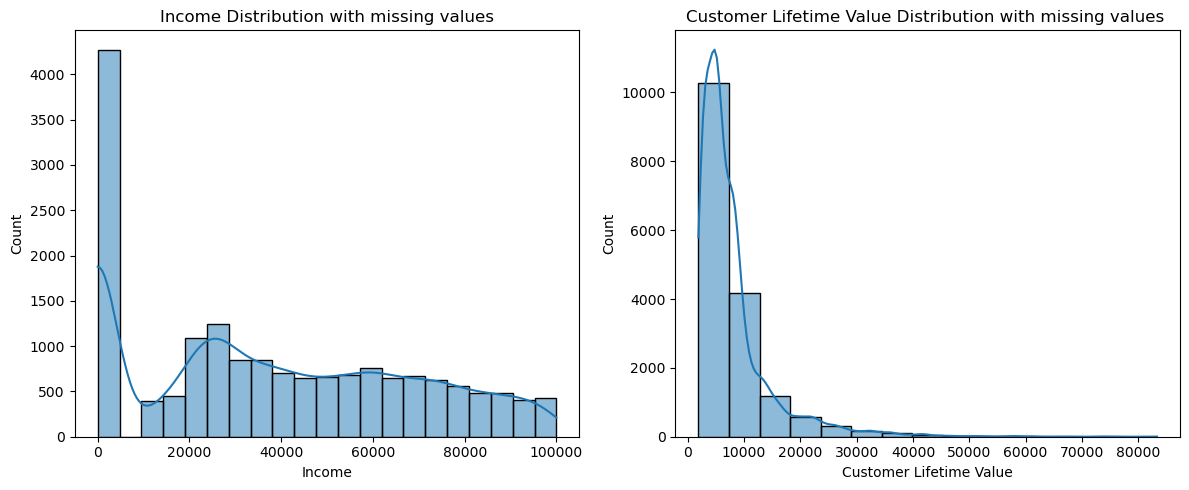

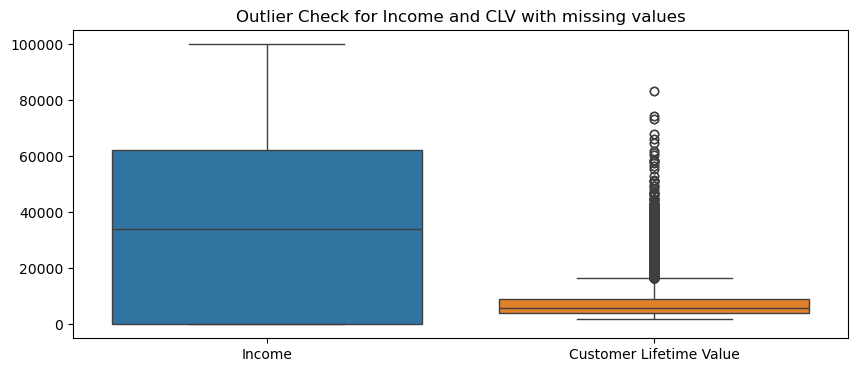

In [9]:

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(customers['Income'],kde=True)
plt.title('Income Distribution with missing values')

plt.subplot(1,2,2)
sns.histplot(customers['Customer Lifetime Value'], bins=15, kde=True)
plt.title('Customer Lifetime Value Distribution with missing values ')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(data=customers[['Income', 'Customer Lifetime Value']])
plt.title('Outlier Check for Income and CLV with missing values')
plt.show()

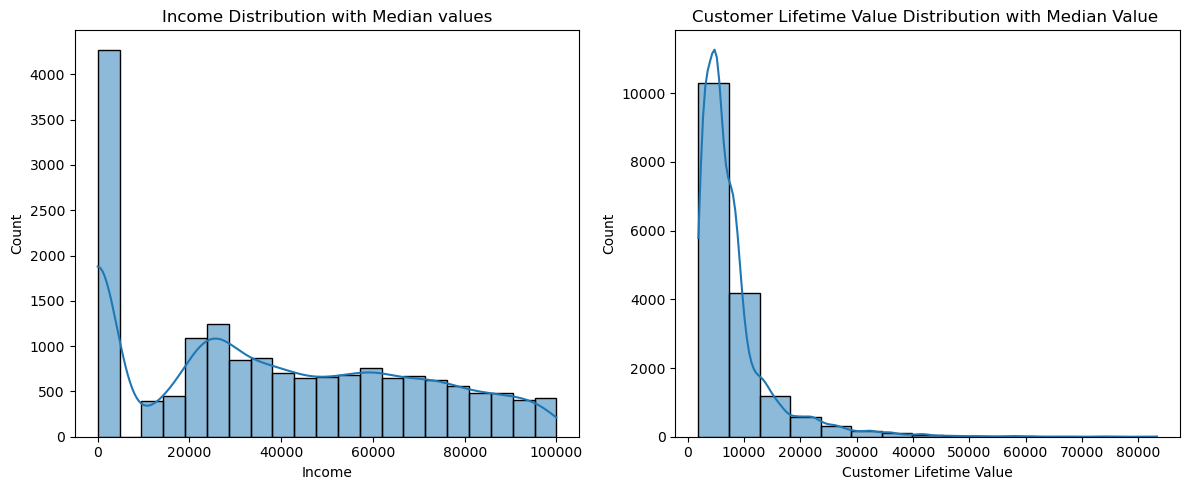

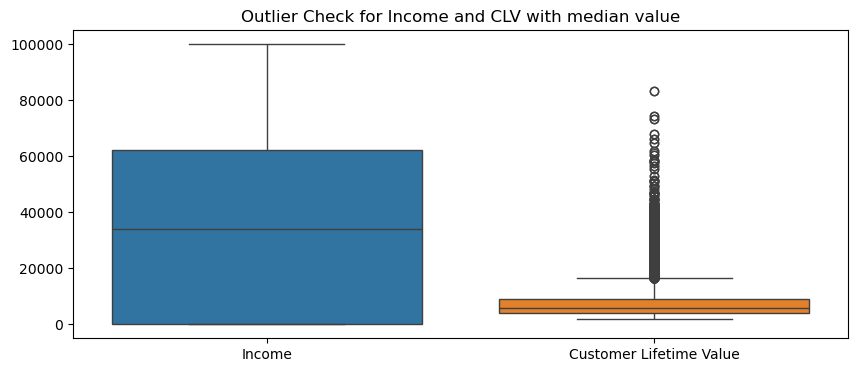

In [10]:
customers_filled_with_median = customers.copy()

#BEst way?
# Income median should be calculated accodring to the factors affecting it. Rather than median of full income?
customers_filled_with_median['Income'] = customers_filled_with_median['Income'].fillna(customers_filled_with_median['Income'].median())
customers_filled_with_median['Customer Lifetime Value'] = customers_filled_with_median['Customer Lifetime Value'].fillna(customers_filled_with_median['Customer Lifetime Value'].median())


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(customers_filled_with_median['Income'],kde=True)
plt.title('Income Distribution with Median values')

plt.subplot(1,2,2)
sns.histplot(customers_filled_with_median['Customer Lifetime Value'], bins=15, kde=True)
plt.title('Customer Lifetime Value Distribution with Median Value ')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10,4))
sns.boxplot(data=customers_filled_with_median[['Income', 'Customer Lifetime Value']])
plt.title('Outlier Check for Income and CLV with median value')
plt.show()

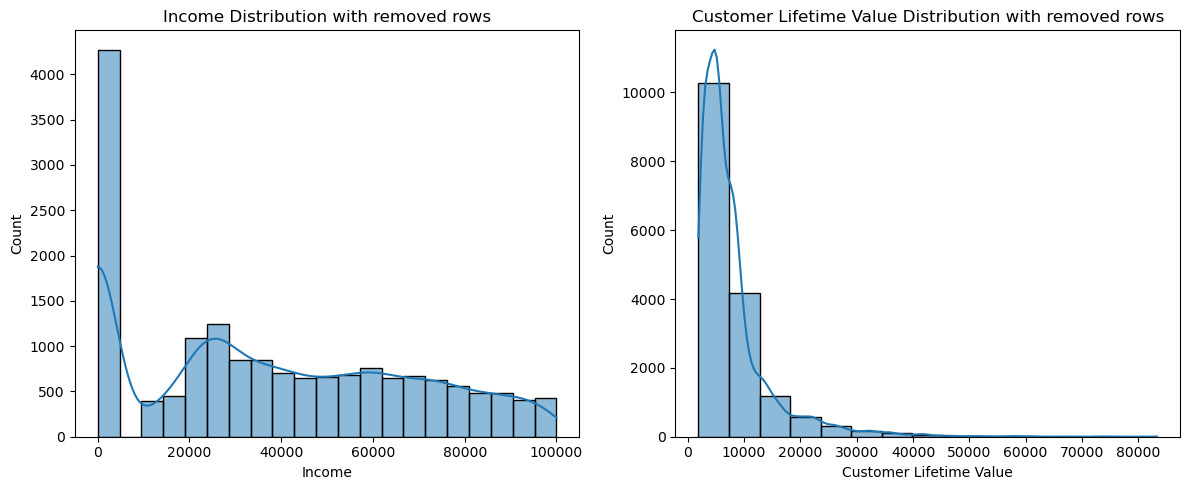

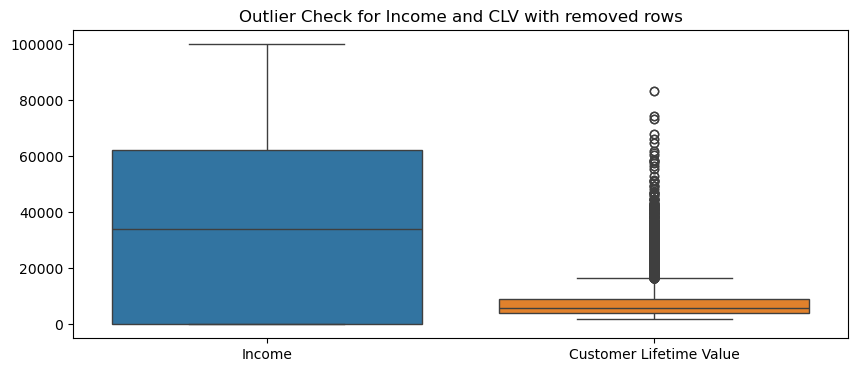

In [11]:
customers_with_na_income_dropped = customers.dropna(subset=['Income', 'Customer Lifetime Value']).copy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(customers_with_na_income_dropped['Income'],kde=True)
plt.title('Income Distribution with removed rows')

plt.subplot(1,2,2)
sns.histplot(customers_with_na_income_dropped['Customer Lifetime Value'], bins=15, kde=True)
plt.title('Customer Lifetime Value Distribution with removed rows')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10,4))
sns.boxplot(data=customers_with_na_income_dropped[['Income', 'Customer Lifetime Value']])
plt.title('Outlier Check for Income and CLV with removed rows')
plt.show()

In [12]:
today = pd.Timestamp.today()

customers['IsActive'] = customers['CancellationDate'].isna()
customers['EffectiveEndDate'] = customers['CancellationDate'].fillna(today)
customers['TenureDays'] = (customers['EffectiveEndDate'] - customers['EnrollmentDateOpening']).dt.days
customers.drop('CancellationDate', axis=1, inplace=True)

sorted_customers = customers.sort_values(by='Loyalty#')
sorted_customers

sorted_flights_per_loyalty = flights.sort_values(by='Loyalty#')
sorted_flights_per_loyalty

combined_flights_data_per_loyalty_no = flights.groupby('Loyalty#').agg({
    'NumFlights': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'DistanceKM': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum',
    'DollarCostPointsRedeemed': 'sum'
}).reset_index()
combined_flights_data_per_loyalty_no

customer_flights_combined = pd.merge(customers, combined_flights_data_per_loyalty_no, on='Loyalty#', how='left')
customer_flights_combined


,Loyalty#,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,...,EnrollmentType,IsActive,EffectiveEndDate,TenureDays,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,480934,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,...,Standard,True,2025-10-18 14:22:00.236649,2437,189.6,56.1,507054.9,50699.39,13517.9,134.6
1,549612,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,...,Standard,True,2025-10-18 14:22:00.236649,2415,279.1,32.2,426827.4,42672.54,22457.8,221.4
2,429460,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,...,Standard,False,2021-01-08 00:00:00.000000,1274,120.0,39.9,238376.1,23832.41,5479.6,53.2
3,608370,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,...,Standard,True,2025-10-18 14:22:00.236649,3531,195.9,58.5,386029.3,38595.63,16331.5,162.2
4,530508,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,...,2021 Promotion,True,2025-10-18 14:22:00.236649,2915,170.7,62.9,369242.6,36916.56,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16916,100012,Ethan Thompson,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,...,Standard,False,2019-02-27 00:00:00.000000,0,NaN,NaN,NaN,NaN,NaN,NaN
16917,100013,Layla Young,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,...,Standard,False,2017-09-20 00:00:00.000000,0,NaN,NaN,NaN,NaN,NaN,NaN
16918,100014,Amelia Bennett,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,...,Standard,False,2020-11-28 00:00:00.000000,0,NaN,NaN,NaN,NaN,NaN,NaN
16919,100015,Benjamin Wilson,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,...,Standard,False,2020-04-09 00:00:00.000000,0,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
combined_flights_data_per_loyalty_no

#Check number of customers who haven't flown with us yet

# Round the Numflights and NumFlights with campanions

# So Numflights & NumFlightsWithCompanions, are they a different field because number of flights and companions need to be whole number

,Loyalty#,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,100018,229.9,49.4,530230.0,53014.30,20562.8,201.9
1,100102,247.7,58.2,339114.6,33903.96,18760.6,186.2
2,100140,216.8,54.2,432030.8,43192.58,4896.0,48.0
3,100214,112.3,19.7,364601.7,36453.77,12908.6,127.3
4,100272,186.4,53.1,429630.5,42953.25,10891.4,107.0
...,...,...,...,...,...,...,...
16732,999902,267.1,75.8,610159.5,61006.55,10501.8,103.1
16733,999911,0.0,0.0,0.0,0.00,0.0,0.0
16734,999940,85.5,28.4,238578.9,23855.59,5620.0,56.0
16735,999982,22.0,2.0,52654.0,5264.00,0.0,0.0


In [14]:
customers_filled_with_median['IsActive'] = customers_filled_with_median['CancellationDate'].isna()
customers_filled_with_median['EffectiveEndDate'] = customers_filled_with_median['CancellationDate'].fillna(today)
customers_filled_with_median['TenureDays'] = (
    customers_filled_with_median['EffectiveEndDate'] - customers_filled_with_median['EnrollmentDateOpening']
).dt.days
customers_filled_with_median.drop('CancellationDate', axis=1, inplace=True)

sorted_customers_filled_with_median = customers_filled_with_median.sort_values(by='Loyalty#')

customer_flights_combined_filled = pd.merge(
    customers_filled_with_median,
    combined_flights_data_per_loyalty_no,
    on='Loyalty#',
    how='left'
)

customer_flights_combined_filled

,Loyalty#,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,...,EnrollmentType,IsActive,EffectiveEndDate,TenureDays,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,480934,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,...,Standard,True,2025-10-18 14:22:00.236649,2437,189.6,56.1,507054.9,50699.39,13517.9,134.6
1,549612,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,...,Standard,True,2025-10-18 14:22:00.236649,2415,279.1,32.2,426827.4,42672.54,22457.8,221.4
2,429460,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,...,Standard,False,2021-01-08 00:00:00.000000,1274,120.0,39.9,238376.1,23832.41,5479.6,53.2
3,608370,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,...,Standard,True,2025-10-18 14:22:00.236649,3531,195.9,58.5,386029.3,38595.63,16331.5,162.2
4,530508,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,...,2021 Promotion,True,2025-10-18 14:22:00.236649,2915,170.7,62.9,369242.6,36916.56,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16916,100012,Ethan Thompson,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,...,Standard,False,2019-02-27 00:00:00.000000,0,NaN,NaN,NaN,NaN,NaN,NaN
16917,100013,Layla Young,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,...,Standard,False,2017-09-20 00:00:00.000000,0,NaN,NaN,NaN,NaN,NaN,NaN
16918,100014,Amelia Bennett,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,...,Standard,False,2020-11-28 00:00:00.000000,0,NaN,NaN,NaN,NaN,NaN,NaN
16919,100015,Benjamin Wilson,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,...,Standard,False,2020-04-09 00:00:00.000000,0,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
customers_with_na_income_dropped['IsActive'] = customers_with_na_income_dropped['CancellationDate'].isna()
customers_with_na_income_dropped['EffectiveEndDate'] = customers_with_na_income_dropped['CancellationDate'].fillna(today)
customers_with_na_income_dropped['TenureDays'] = (
    customers_with_na_income_dropped['EffectiveEndDate'] - customers_with_na_income_dropped['EnrollmentDateOpening']
).dt.days
customers_with_na_income_dropped.drop('CancellationDate', axis=1, inplace=True)

sorted_customers_with_na_income_dropped = customers_with_na_income_dropped.sort_values(by='Loyalty#')

customer_flights_combined_dropped = pd.merge(
    customers_with_na_income_dropped,
    combined_flights_data_per_loyalty_no,
    on='Loyalty#',
    how='left'
)
customer_flights_combined_dropped

,Loyalty#,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,...,EnrollmentType,IsActive,EffectiveEndDate,TenureDays,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,480934,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,...,Standard,True,2025-10-18 14:22:00.236649,2437,189.6,56.1,507054.9,50699.39,13517.9,134.6
1,549612,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,...,Standard,True,2025-10-18 14:22:00.236649,2415,279.1,32.2,426827.4,42672.54,22457.8,221.4
2,429460,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,...,Standard,False,2021-01-08 00:00:00.000000,1274,120.0,39.9,238376.1,23832.41,5479.6,53.2
3,608370,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,...,Standard,True,2025-10-18 14:22:00.236649,3531,195.9,58.5,386029.3,38595.63,16331.5,162.2
4,530508,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,...,2021 Promotion,True,2025-10-18 14:22:00.236649,2915,170.7,62.9,369242.6,36916.56,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16896,823768,Mandy Sammarco,British Columbia,Vancouver,49.282730,-123.120740,V6E 3Z3,female,College,Rural,...,Standard,True,2025-10-18 14:22:00.236649,3588,170.1,15.7,414936.3,41487.73,0.0,0.0
16897,680886,Jamee Ahlm,Saskatchewan,Regina,50.445210,-104.618900,S1J 3C5,female,Bachelor,Rural,...,Standard,True,2025-10-18 14:22:00.236649,2964,269.1,60.3,362649.6,36253.76,16434.8,162.7
16898,776187,Janina Lumb,British Columbia,Vancouver,49.282730,-123.120740,V5R 1W3,male,College,Urban,...,Standard,True,2025-10-18 14:22:00.236649,3130,256.8,45.6,486378.9,48628.99,15733.0,156.3
16899,615459,Dannie Paplow,Quebec,Montreal,45.501690,-73.567253,H2Y 4R4,male,Bachelor,Urban,...,2021 Promotion,False,2021-12-22 00:00:00.000000,244,53.0,22.0,62696.0,6266.00,5247.0,52.0


In [16]:
missing_flights = customers[~customers['Loyalty#'].isin(flights['Loyalty#'])]
print(f"Customers with no flight data: {len(missing_flights)}")

Customers with no flight data: 20


In [17]:
flight_cols = ['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM',
               'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed']

customer_flights_combined[flight_cols] = customer_flights_combined[flight_cols].fillna(0)
customer_flights_combined_dropped[flight_cols] = customer_flights_combined_dropped[flight_cols].fillna(0)
customer_flights_combined_filled[flight_cols] = customer_flights_combined_filled[flight_cols].fillna(0)


#Ammar's suggestion. Instead of making it 0, Drop it

In [18]:
customer_flights_combined

,Loyalty#,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,...,EnrollmentType,IsActive,EffectiveEndDate,TenureDays,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,480934,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,...,Standard,True,2025-10-18 14:22:00.236649,2437,189.6,56.1,507054.9,50699.39,13517.9,134.6
1,549612,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,...,Standard,True,2025-10-18 14:22:00.236649,2415,279.1,32.2,426827.4,42672.54,22457.8,221.4
2,429460,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,...,Standard,False,2021-01-08 00:00:00.000000,1274,120.0,39.9,238376.1,23832.41,5479.6,53.2
3,608370,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,...,Standard,True,2025-10-18 14:22:00.236649,3531,195.9,58.5,386029.3,38595.63,16331.5,162.2
4,530508,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,...,2021 Promotion,True,2025-10-18 14:22:00.236649,2915,170.7,62.9,369242.6,36916.56,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16916,100012,Ethan Thompson,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,...,Standard,False,2019-02-27 00:00:00.000000,0,0.0,0.0,0.0,0.00,0.0,0.0
16917,100013,Layla Young,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,...,Standard,False,2017-09-20 00:00:00.000000,0,0.0,0.0,0.0,0.00,0.0,0.0
16918,100014,Amelia Bennett,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,...,Standard,False,2020-11-28 00:00:00.000000,0,0.0,0.0,0.0,0.00,0.0,0.0
16919,100015,Benjamin Wilson,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,...,Standard,False,2020-04-09 00:00:00.000000,0,0.0,0.0,0.0,0.00,0.0,0.0


In [19]:
customer_flights_combined_dropped

,Loyalty#,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,...,EnrollmentType,IsActive,EffectiveEndDate,TenureDays,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,480934,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,...,Standard,True,2025-10-18 14:22:00.236649,2437,189.6,56.1,507054.9,50699.39,13517.9,134.6
1,549612,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,...,Standard,True,2025-10-18 14:22:00.236649,2415,279.1,32.2,426827.4,42672.54,22457.8,221.4
2,429460,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,...,Standard,False,2021-01-08 00:00:00.000000,1274,120.0,39.9,238376.1,23832.41,5479.6,53.2
3,608370,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,...,Standard,True,2025-10-18 14:22:00.236649,3531,195.9,58.5,386029.3,38595.63,16331.5,162.2
4,530508,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,...,2021 Promotion,True,2025-10-18 14:22:00.236649,2915,170.7,62.9,369242.6,36916.56,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16896,823768,Mandy Sammarco,British Columbia,Vancouver,49.282730,-123.120740,V6E 3Z3,female,College,Rural,...,Standard,True,2025-10-18 14:22:00.236649,3588,170.1,15.7,414936.3,41487.73,0.0,0.0
16897,680886,Jamee Ahlm,Saskatchewan,Regina,50.445210,-104.618900,S1J 3C5,female,Bachelor,Rural,...,Standard,True,2025-10-18 14:22:00.236649,2964,269.1,60.3,362649.6,36253.76,16434.8,162.7
16898,776187,Janina Lumb,British Columbia,Vancouver,49.282730,-123.120740,V5R 1W3,male,College,Urban,...,Standard,True,2025-10-18 14:22:00.236649,3130,256.8,45.6,486378.9,48628.99,15733.0,156.3
16899,615459,Dannie Paplow,Quebec,Montreal,45.501690,-73.567253,H2Y 4R4,male,Bachelor,Urban,...,2021 Promotion,False,2021-12-22 00:00:00.000000,244,53.0,22.0,62696.0,6266.00,5247.0,52.0


In [20]:
customer_flights_combined_filled

,Loyalty#,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,...,EnrollmentType,IsActive,EffectiveEndDate,TenureDays,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,480934,Cecilia Householder,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,...,Standard,True,2025-10-18 14:22:00.236649,2437,189.6,56.1,507054.9,50699.39,13517.9,134.6
1,549612,Dayle Menez,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,...,Standard,True,2025-10-18 14:22:00.236649,2415,279.1,32.2,426827.4,42672.54,22457.8,221.4
2,429460,Necole Hannon,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,...,Standard,False,2021-01-08 00:00:00.000000,1274,120.0,39.9,238376.1,23832.41,5479.6,53.2
3,608370,Queen Hagee,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,...,Standard,True,2025-10-18 14:22:00.236649,3531,195.9,58.5,386029.3,38595.63,16331.5,162.2
4,530508,Claire Latting,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,...,2021 Promotion,True,2025-10-18 14:22:00.236649,2915,170.7,62.9,369242.6,36916.56,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16916,100012,Ethan Thompson,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,...,Standard,False,2019-02-27 00:00:00.000000,0,0.0,0.0,0.0,0.00,0.0,0.0
16917,100013,Layla Young,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,...,Standard,False,2017-09-20 00:00:00.000000,0,0.0,0.0,0.0,0.00,0.0,0.0
16918,100014,Amelia Bennett,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,...,Standard,False,2020-11-28 00:00:00.000000,0,0.0,0.0,0.0,0.00,0.0,0.0
16919,100015,Benjamin Wilson,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,...,Standard,False,2020-04-09 00:00:00.000000,0,0.0,0.0,0.0,0.00,0.0,0.0


In [21]:
print("\n--- Missing Values in Real Dataset ---")
print(customer_flights_combined.isna().sum().sort_values(ascending=False))

print("\n--- Missing Values in Dataset with dropped values ---")
print(customer_flights_combined_dropped.isna().sum().sort_values(ascending=False))

print("\n--- Missing Values in Dataset with filled values ---")
print(customer_flights_combined_filled.isna().sum().sort_values(ascending=False))


--- Missing Values in Real Dataset ---
Income                      20
Customer Lifetime Value     20
Province or State            0
Customer Name                0
Latitude                     0
Longitude                    0
Postal code                  0
City                         0
Loyalty#                     0
Education                    0
Gender                       0
Marital Status               0
Location Code                0
LoyaltyStatus                0
EnrollmentDateOpening        0
EnrollmentType               0
IsActive                     0
EffectiveEndDate             0
TenureDays                   0
NumFlights                   0
NumFlightsWithCompanions     0
DistanceKM                   0
PointsAccumulated            0
PointsRedeemed               0
DollarCostPointsRedeemed     0
dtype: int64

--- Missing Values in Dataset with dropped values ---
Loyalty#                    0
Customer Name               0
Province or State           0
City                       

In [22]:
customers_with_na_income_dropped['EnrollmentDateOpening'] = pd.to_datetime(customers_with_na_income_dropped['EnrollmentDateOpening'], errors='coerce')
customers_with_na_income_dropped['EffectiveEndDate'] = pd.to_datetime(customers_with_na_income_dropped['EffectiveEndDate'], errors='coerce')

In [23]:
for name, df in {
    "Original": customer_flights_combined,
    "Dropped NAs": customer_flights_combined_dropped,
    "Filled with Median": customer_flights_combined_filled
}.items():
    print(f"\n{name} Dataset:")
    print(df.shape)
    print(df.isna().sum())
    print(df.describe())


Original Dataset:
(16921, 25)
Loyalty#                     0
Customer Name                0
Province or State            0
City                         0
Latitude                     0
Longitude                    0
Postal code                  0
Gender                       0
Education                    0
Location Code                0
Income                      20
Marital Status               0
LoyaltyStatus                0
EnrollmentDateOpening        0
Customer Lifetime Value     20
EnrollmentType               0
IsActive                     0
EffectiveEndDate             0
TenureDays                   0
NumFlights                   0
NumFlightsWithCompanions     0
DistanceKM                   0
PointsAccumulated            0
PointsRedeemed               0
DollarCostPointsRedeemed     0
dtype: int64
            Loyalty#      Latitude     Longitude        Income  \
count   16921.000000  16921.000000  16921.000000  16901.000000   
mean   550197.393771     47.174500    -91.814768 

In [24]:
df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Loyalty#                  16921 non-null  int64         
 1   Customer Name             16921 non-null  object        
 2   Province or State         16921 non-null  object        
 3   City                      16921 non-null  object        
 4   Latitude                  16921 non-null  float64       
 5   Longitude                 16921 non-null  float64       
 6   Postal code               16921 non-null  object        
 7   Gender                    16921 non-null  object        
 8   Education                 16921 non-null  object        
 9   Location Code             16921 non-null  object        
 10  Income                    16921 non-null  float64       
 11  Marital Status            16921 non-null  object        
 12  LoyaltyStatus     

,Loyalty#,Customer Name,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,...,EnrollmentType,IsActive,EffectiveEndDate,TenureDays,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
count,16921.000000,16921,16921,16921,16921.000000,16921.000000,16921,16921,16921,16921,...,16921,16921,16921,16921.000000,16921.000000,16921.000000,1.692100e+04,16921.000000,16921.000000,16921.000000
unique,NaN,16921,11,29,NaN,NaN,75,2,5,3,...,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Emma Martin,Ontario,Toronto,NaN,NaN,V6E 3D9,female,Bachelor,Suburban,...,Standard,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,5468,3390,NaN,NaN,917,8497,10586,5716,...,15773,14613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,550197.393771,NaN,NaN,NaN,47.174500,-91.814768,NaN,NaN,NaN,NaN,...,NaN,NaN,2024-12-31 08:16:46.974656,2278.418238,142.598948,35.916004,2.898066e+05,28974.948924,8580.661533,84.797057
min,100011.000000,NaN,NaN,NaN,42.984924,-135.056840,NaN,NaN,NaN,NaN,...,NaN,NaN,2015-01-27 00:00:00,-1924.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,326823.000000,NaN,NaN,NaN,44.231171,-120.237660,NaN,NaN,NaN,NaN,...,NaN,NaN,2025-10-18 14:22:00.236648960,1662.000000,70.000000,15.800000,1.426110e+05,14257.000000,0.000000,0.000000
50%,550896.000000,NaN,NaN,NaN,46.087818,-79.383186,NaN,NaN,NaN,NaN,...,NaN,NaN,2025-10-18 14:22:00.236648960,2352.000000,163.000000,36.800000,3.315894e+05,33152.440000,6521.000000,64.600000
75%,772438.000000,NaN,NaN,NaN,49.282730,-74.596184,NaN,NaN,NaN,NaN,...,NaN,NaN,2025-10-18 14:22:00.236648960,3127.000000,204.000000,52.900000,4.146723e+05,41459.430000,13647.200000,134.900000
max,999999.000000,NaN,NaN,NaN,60.721188,-52.712578,NaN,NaN,NaN,NaN,...,NaN,NaN,2025-10-18 14:22:00.236649,3853.000000,539.400000,144.700000,1.059681e+06,105951.600000,57527.800000,572.000000


In [25]:
df.corr(numeric_only=True)

,Loyalty#,Latitude,Longitude,Income,Customer Lifetime Value,IsActive,TenureDays,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
Loyalty#,1.000000,0.011100,-0.004143,-0.007924,-0.002726,-0.002056,-0.007823,-0.005253,-0.009853,-0.005407,-0.005406,0.002846,0.002887
Latitude,0.011100,1.000000,-0.764840,-0.002034,-0.002278,0.002361,0.001810,0.003484,-0.000992,0.001953,0.001952,-0.010679,-0.010640
Longitude,-0.004143,-0.764840,1.000000,0.002874,0.006071,-0.006123,-0.002679,-0.005106,-0.004541,-0.006649,-0.006649,0.006284,0.006256
Income,-0.007924,-0.002034,0.002874,1.000000,0.024069,0.001516,0.003784,-0.003496,-0.003804,0.001526,0.001526,-0.010599,-0.010622
Customer Lifetime Value,-0.002726,-0.002278,0.006071,0.024069,1.000000,-0.008691,-0.007799,-0.005122,-0.008986,-0.009787,-0.009787,-0.002854,-0.002941
IsActive,-0.002056,0.002361,-0.006123,0.001516,-0.008691,1.000000,0.729859,0.464501,0.405565,0.469130,0.469113,0.266287,0.266095
TenureDays,-0.007823,0.001810,-0.002679,0.003784,-0.007799,0.729859,1.000000,0.639481,0.559180,0.642562,0.642550,0.365280,0.365025
NumFlights,-0.005253,0.003484,-0.005106,-0.003496,-0.005122,0.464501,0.639481,1.000000,0.835629,0.921127,0.921114,0.521302,0.520986
NumFlightsWithCompanions,-0.009853,-0.000992,-0.004541,-0.003804,-0.008986,0.405565,0.559180,0.835629,1.000000,0.803516,0.803504,0.573575,0.573232
DistanceKM,-0.005407,0.001953,-0.006649,0.001526,-0.009787,0.469130,0.642562,0.921127,0.803516,1.000000,1.000000,0.522546,0.522192


In [26]:
### Checking if any columns have single unique value e.g Country was dropped as it only had Canada #######
for col in df.columns:
    if len(df[col].unique()) == 2:
        print(col)
        

Gender
EnrollmentType
IsActive


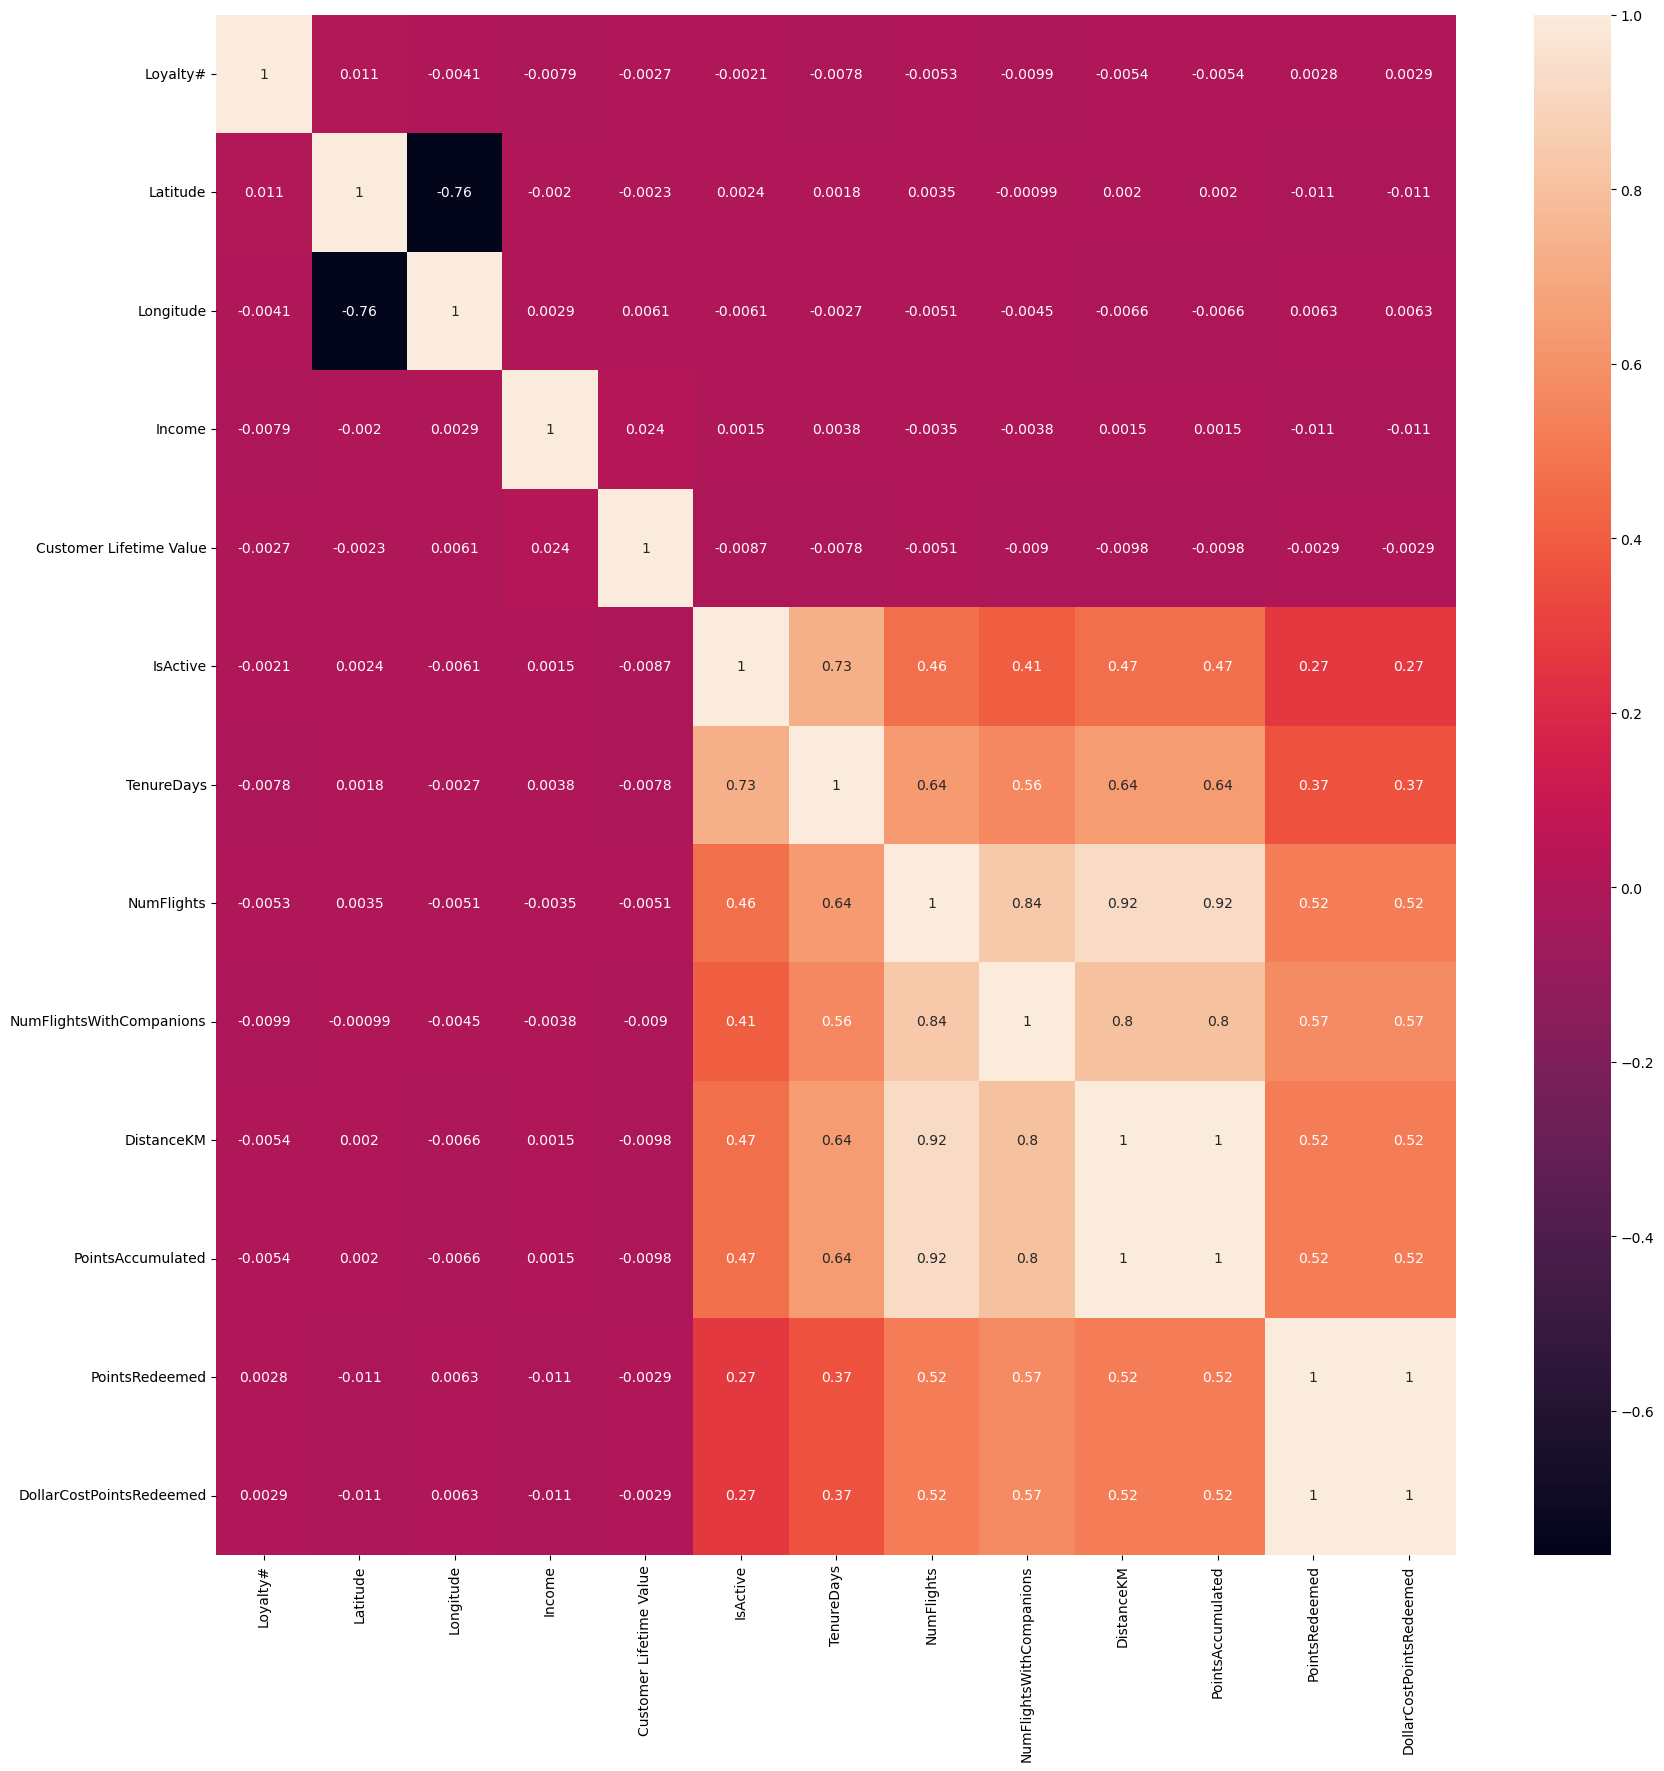

In [27]:
corr = df.corr(numeric_only=True, method="pearson")

fig = plt.figure(figsize=(20, 20))

####
sns.heatmap(data=corr, annot=True, )
####

plt.show()

# Improve
    # Round
    # Lower or upper triangle only
    # Mask values 
    # Divergent color map

<Axes: >

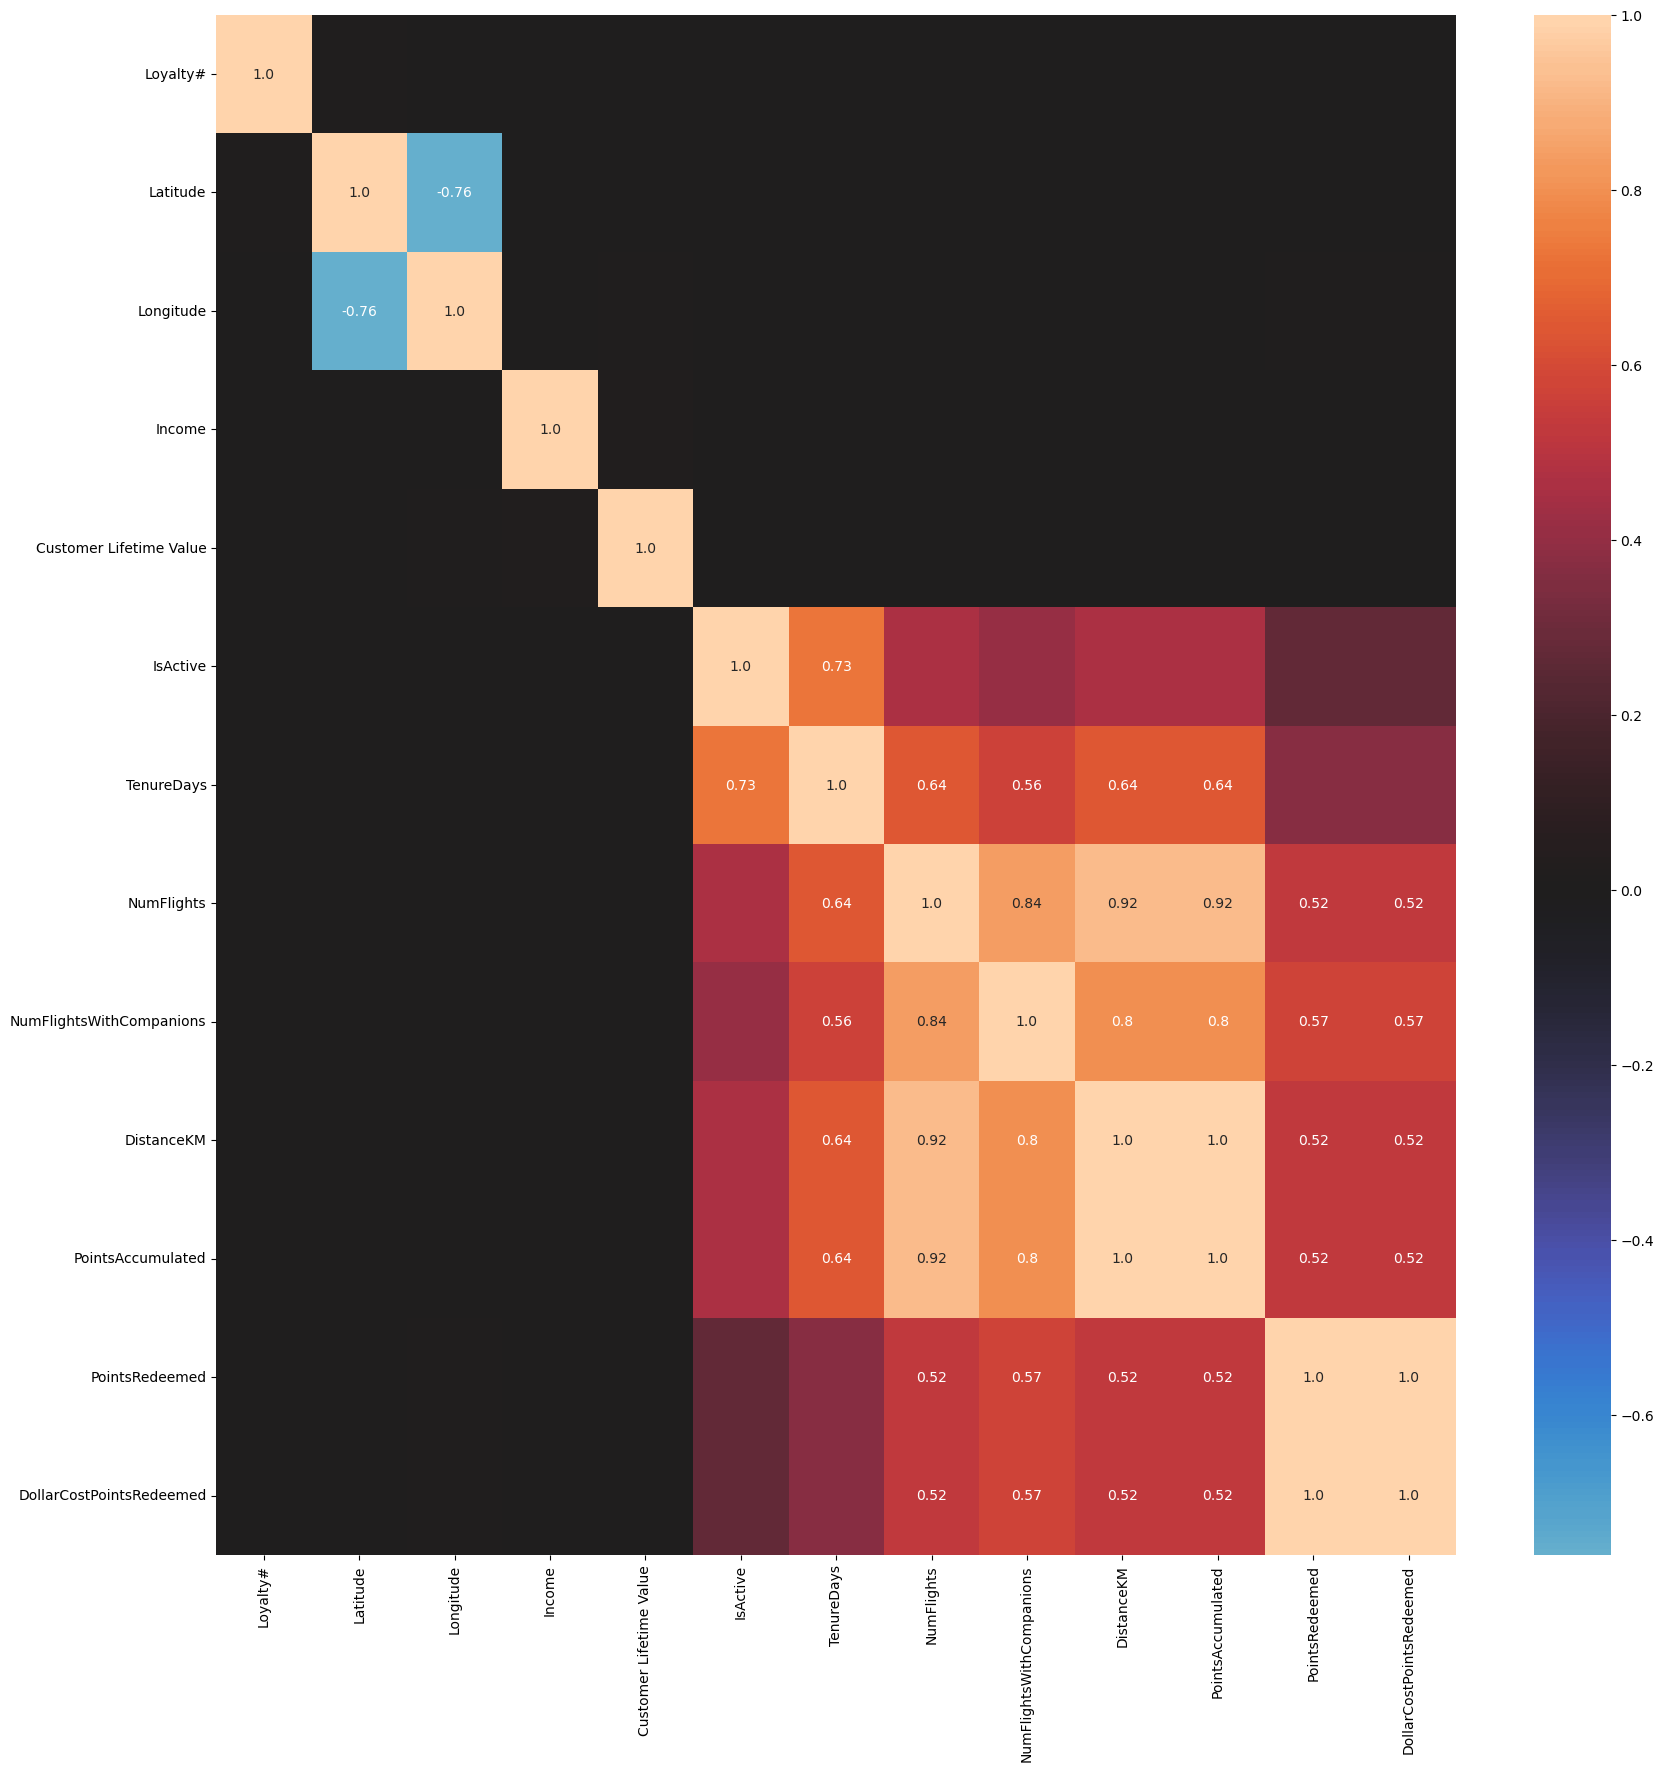

In [28]:
corr = corr.round(2)
mask_annot = np.absolute(corr.values) >= 0.5 


# # Try to understand what this np.where() does
annot = np.where(mask_annot, corr.values, np.full(corr.shape,"")) 

fig = plt.figure(figsize=(20, 20))

sns.heatmap(data=corr, annot=annot, fmt="", center=0)


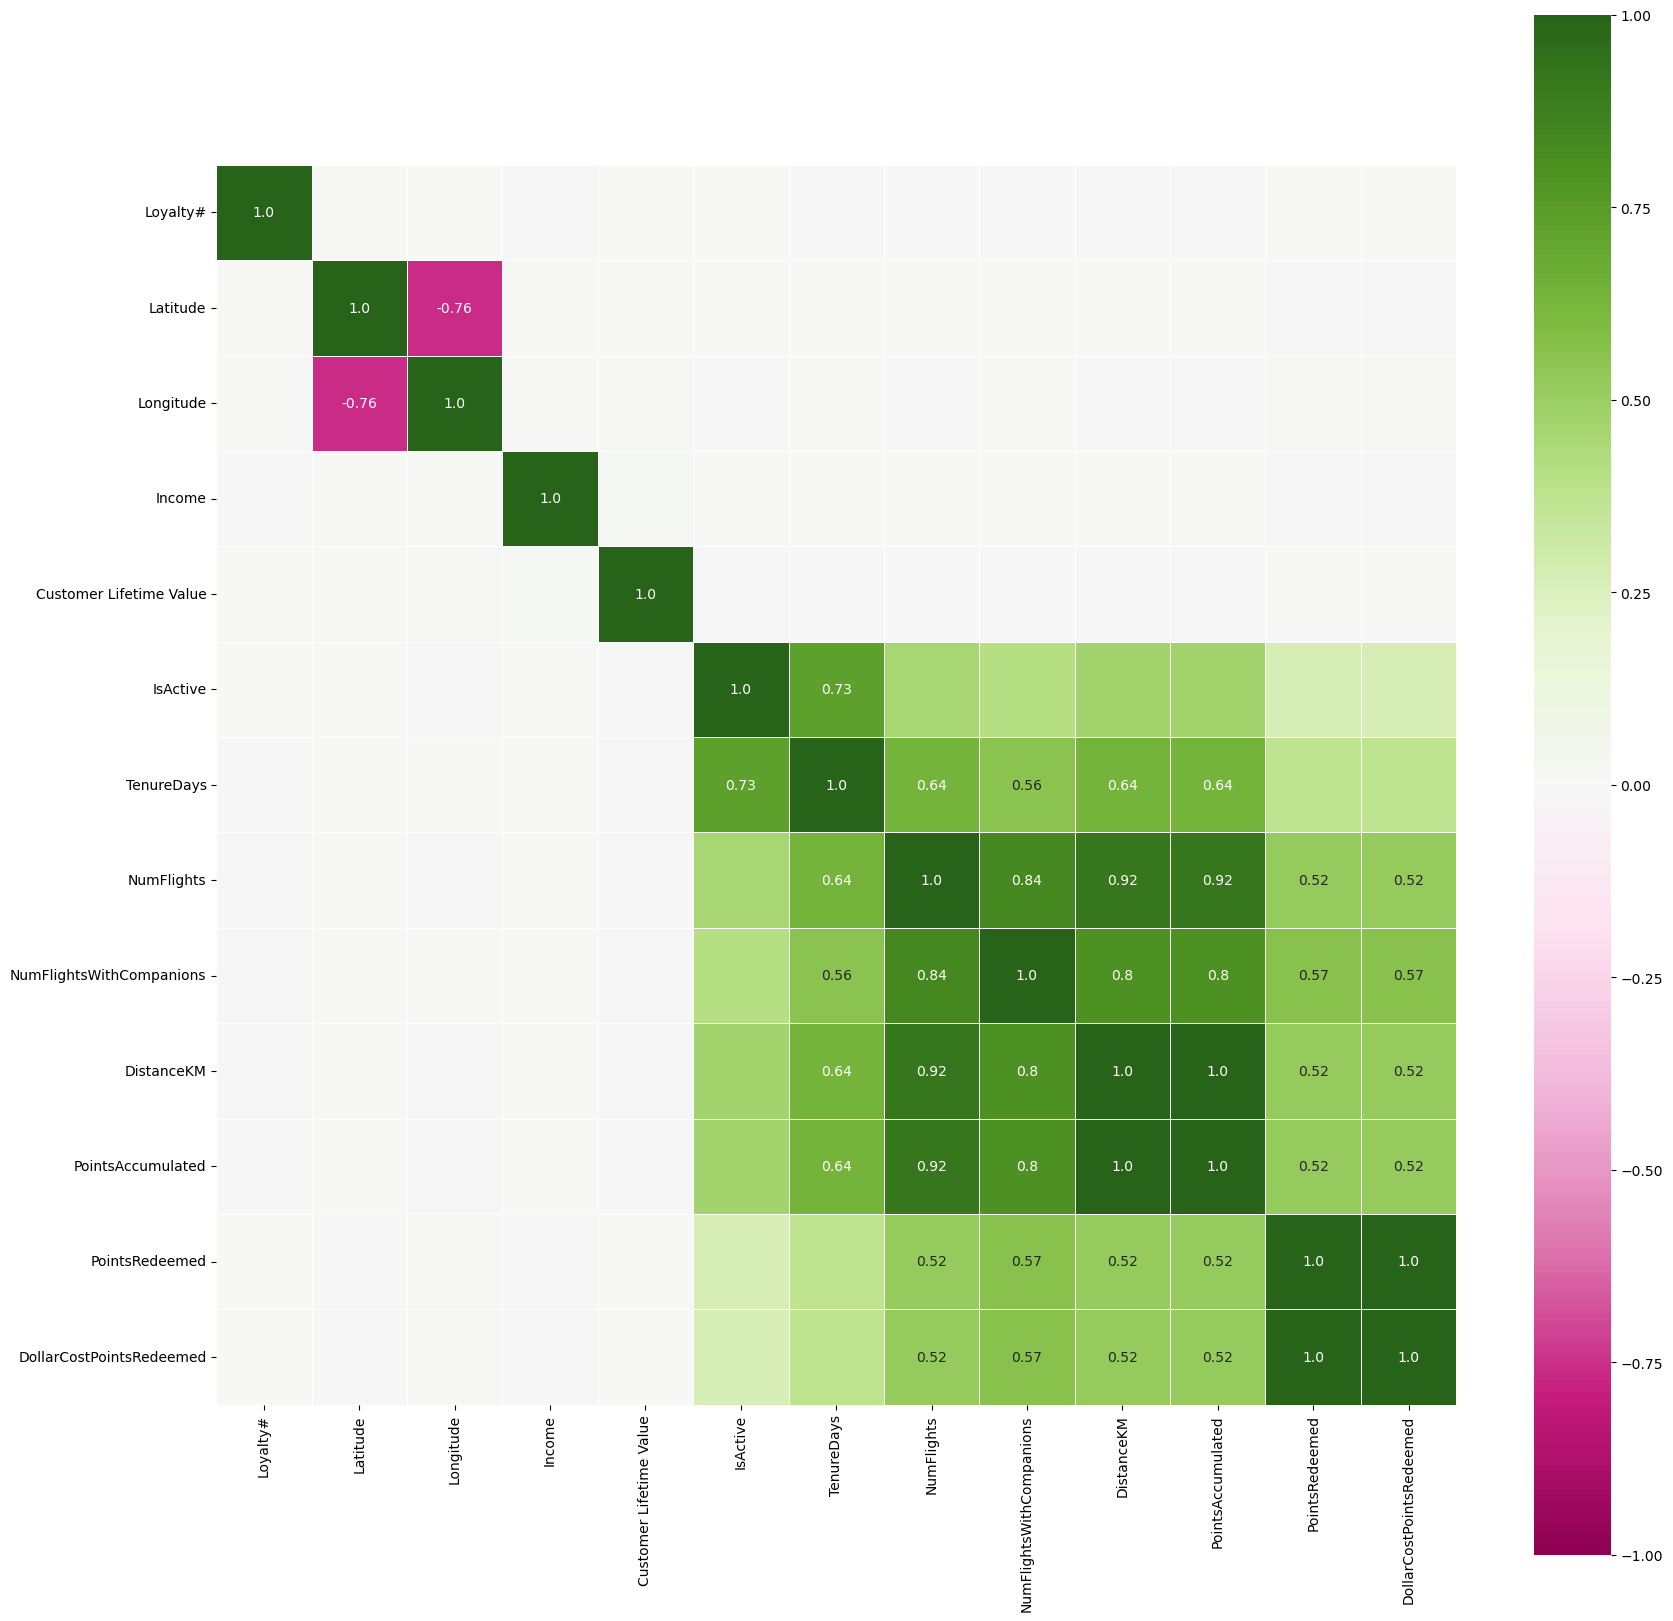

In [29]:
# # Prepare figure
fig = plt.figure(figsize=(20, 20))


# # Plot heatmap of the correlation matrix
sns.heatmap(data=corr, 
            annot=annot, # Specify custom annotation
            fmt='s', # The annotation matrix now has strings, so we need to explicitly say this
            vmin=-1, vmax=1, 
            center=0, # Center the colormap at zero
            square=True, # Make each cell square-shaped
            linewidths=.5, # Add lines between cells
            cmap='PiYG' # Diverging color map
            )

# ## Once you are happy, save this as an image
# # plt.savefig(os.path.join('..', 'figures', 'eda', 'correlation_matrix.png'), dpi=200)

plt.show()


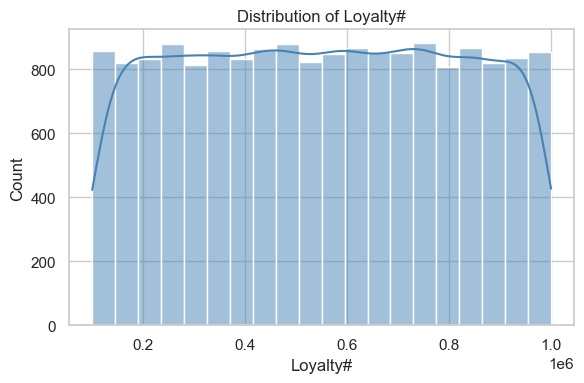

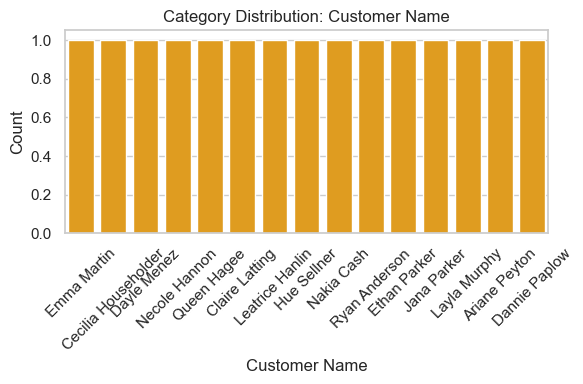

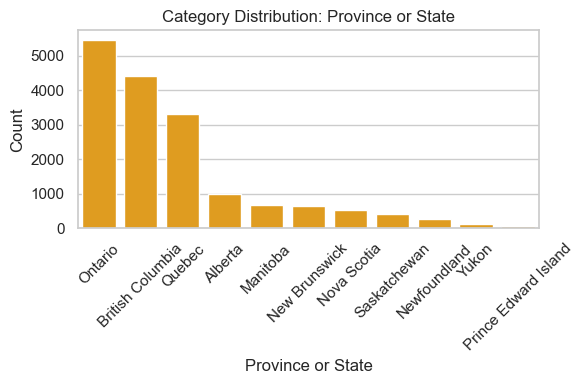

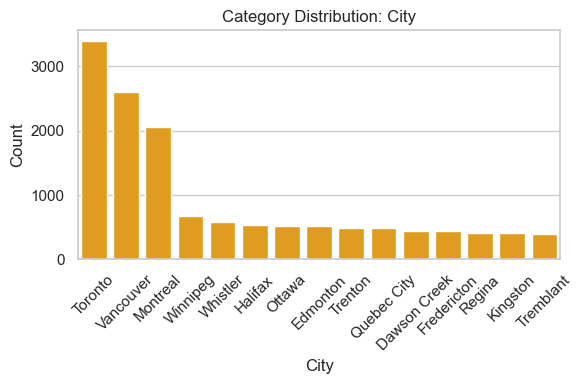

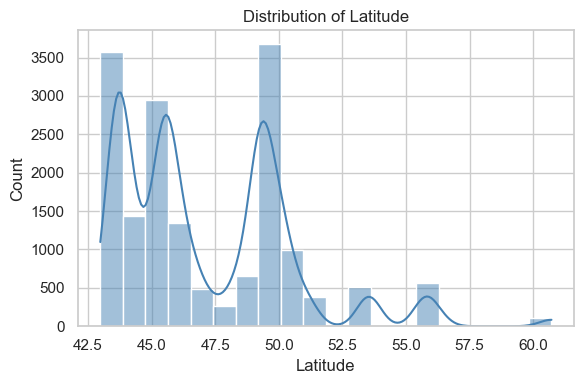

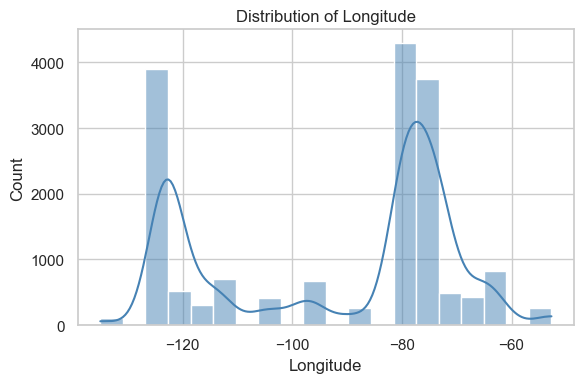

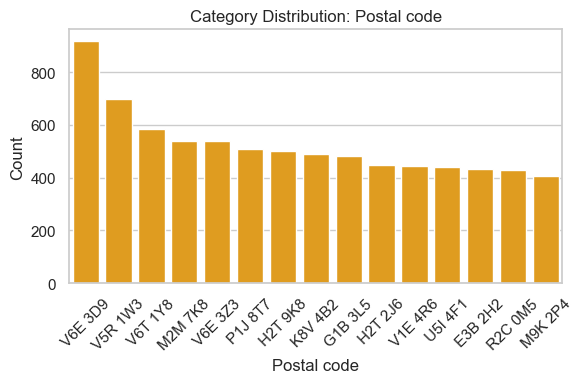

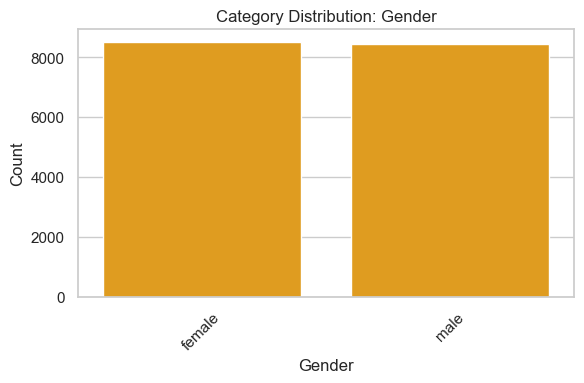

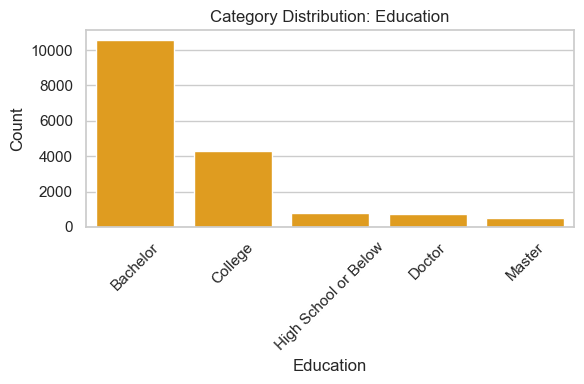

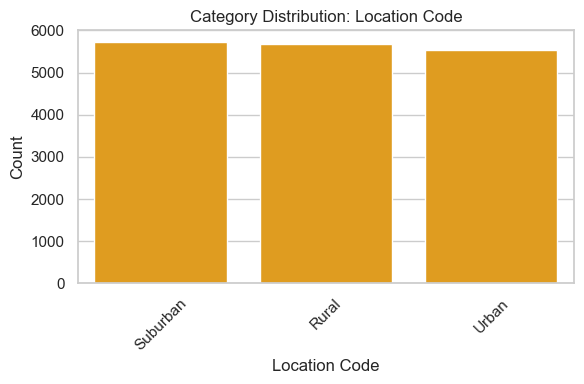

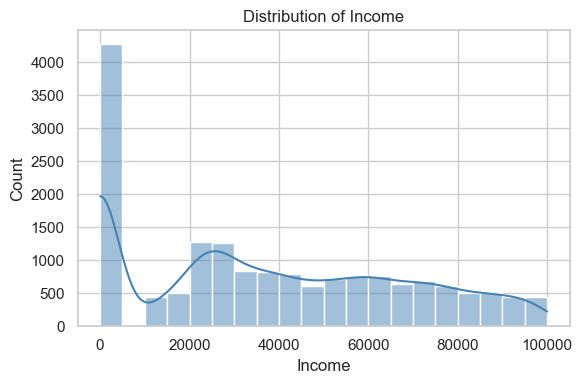

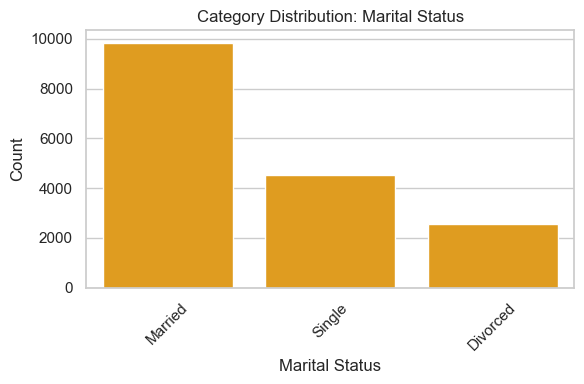

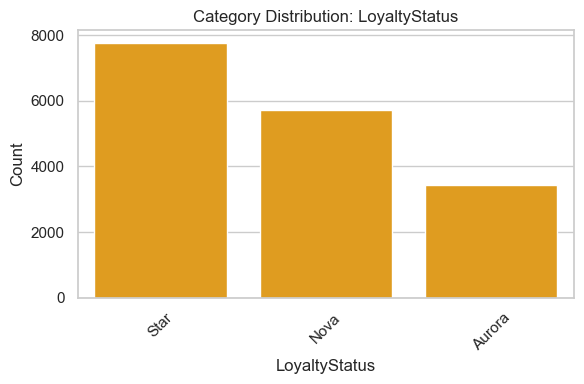

/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_23743/3635224820.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_object_dtype(df[column]) or pd.api.types.is_categorical_dtype(df[column]):


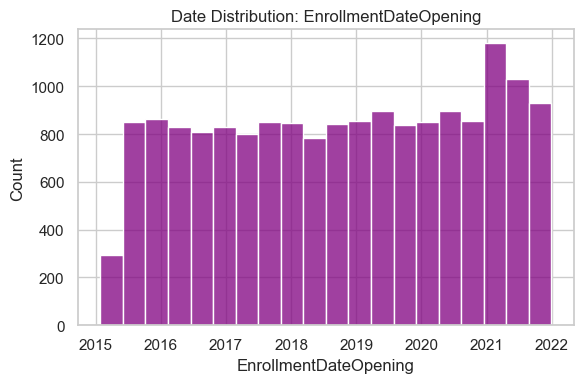

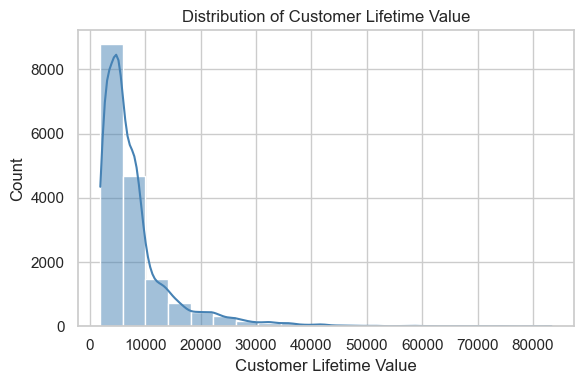

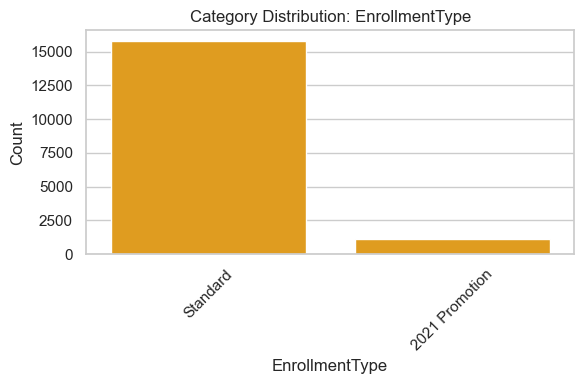

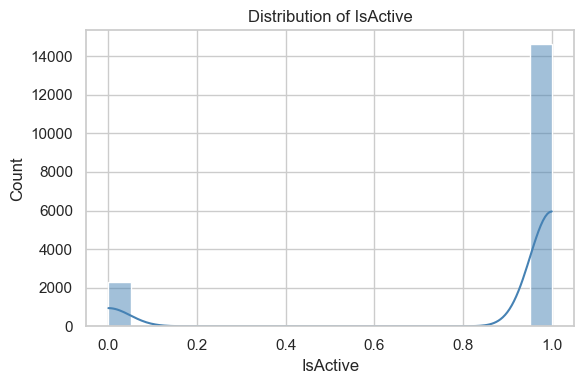

/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_23743/3635224820.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_object_dtype(df[column]) or pd.api.types.is_categorical_dtype(df[column]):


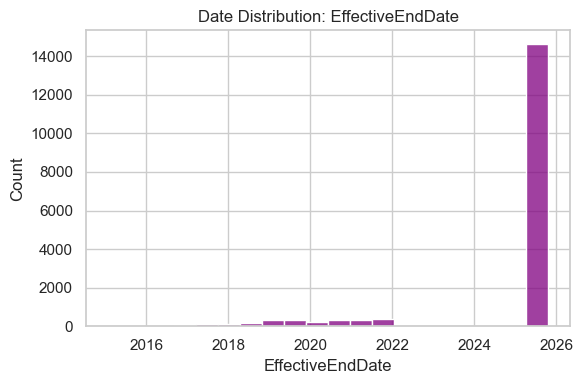

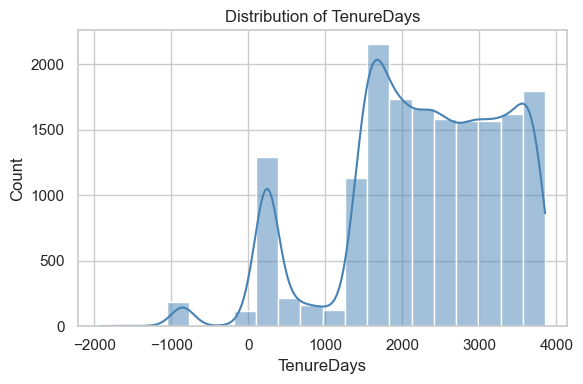

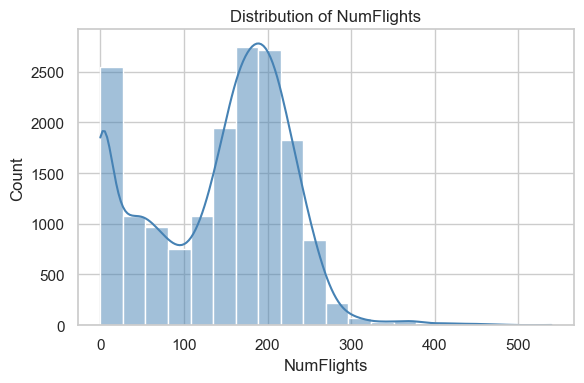

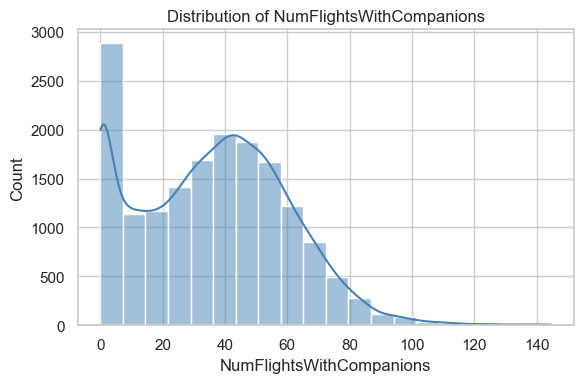

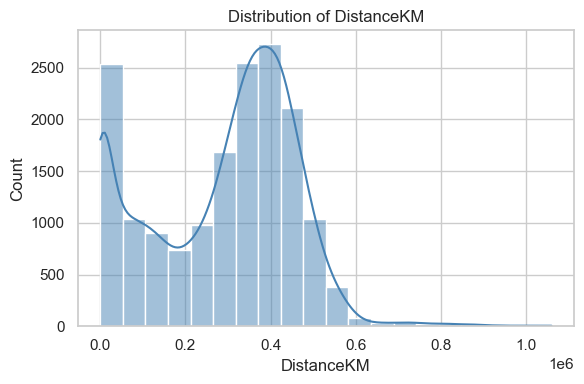

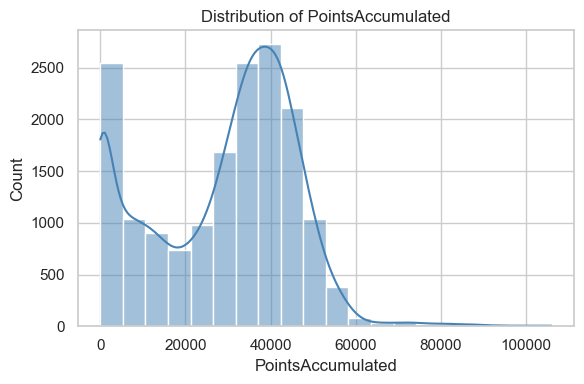

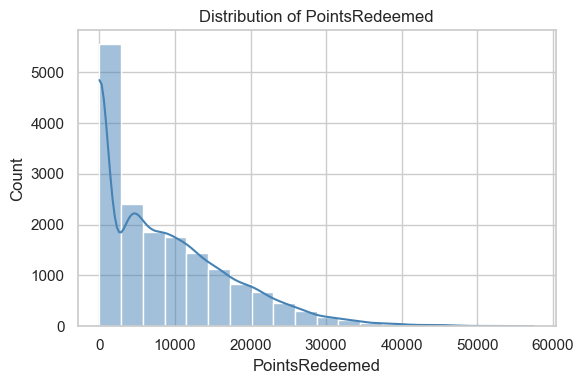

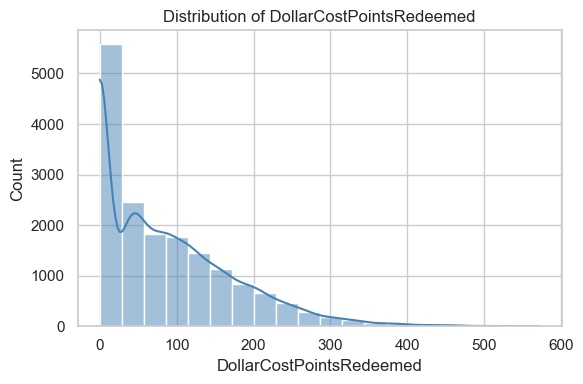

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", palette="muted")

def visualize_dataframe(df):
    for column in df.columns:
        plt.figure(figsize=(6, 4))

        # --- 1. Numeric Columns ---
        if pd.api.types.is_numeric_dtype(df[column]):
            sns.histplot(df[column], kde=True, bins=20, color='steelblue')
            plt.title(f"Distribution of {column}")
            plt.xlabel(column)
            plt.ylabel("Count")

        # --- 2. Categorical Columns ---
        elif pd.api.types.is_object_dtype(df[column]) or pd.api.types.is_categorical_dtype(df[column]):
            value_counts = df[column].value_counts().head(15)  # top 15 categories
            sns.barplot(x=value_counts.index, y=value_counts.values, color='orange')
            plt.title(f"Category Distribution: {column}")
            plt.xticks(rotation=45)
            plt.xlabel(column)
            plt.ylabel("Count")

        # --- 3. Boolean Columns ---
        elif pd.api.types.is_bool_dtype(df[column]):
            sns.countplot(x=df[column], color='green')
            plt.title(f"Boolean Distribution: {column}")
            plt.xlabel(column)
            plt.ylabel("Count")

        # --- 4. Datetime Columns ---
        elif pd.api.types.is_datetime64_any_dtype(df[column]):
            sns.histplot(df[column], bins=20, color='purple')
            plt.title(f"Date Distribution: {column}")
            plt.xlabel(column)
            plt.ylabel("Count")

        plt.tight_layout()
        plt.show()
visualize_dataframe(df)